In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib
from matplotlib.patches import Patch
#no_yellow_viridis = matplotlib.colors.ListedColormap(matplotlib.cm.get_cmap('viridis', 256)(np.linspace(0,0.85,256)))

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest

custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

Loading in data

In [2]:
#establishing  metadata paths
#MC reps
yaml_path_1_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R1_96well'/'Single_cell_csvs'/'wells.yaml'
yaml_path_2_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R2_96well'/'Single_cell_csvs'/'wells.yaml'
yaml_path_12_6 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R12_6well'/'Single_cell_csvs'/'wells.yaml'

#BAD reps
yaml_path_plate3 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'plate3.yaml'
yaml_path_plate4 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'plate4.yaml'
yaml_path_plate5 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'plate5.yaml'
yaml_path_6wells = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'6-wells.yaml'

In [3]:
#establishing single cell csv paths
#MC reps
data_path_1_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R1_96well'/'Single_cell_csvs'
data_path_2_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R2_96well'/'Single_cell_csvs'
data_path_12_6 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R12_6well'/'Single_cell_csvs'

#BAD reps
data_path_plate3 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_plate3'
data_path_plate4 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_plate4'
data_path_plate5 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_plate5'
data_path_6wells = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_6-wells'

In [4]:
#loading data
#MC data
df_1_96 = rd.flow.load_csv_with_metadata(data_path_1_96, yaml_path_1_96)
df_2_96 = rd.flow.load_csv_with_metadata(data_path_2_96, yaml_path_2_96)
df_6 = rd.flow.load_csv_with_metadata(data_path_12_6, yaml_path_12_6)

#BAD data
df_plate3 = rd.flow.load_csv_with_metadata(data_path_plate3, yaml_path_plate3)
df_plate4 = rd.flow.load_csv_with_metadata(data_path_plate4, yaml_path_plate4)
df_plate5 = rd.flow.load_csv_with_metadata(data_path_plate5, yaml_path_plate5)
df_6wells = rd.flow.load_csv_with_metadata(data_path_6wells, yaml_path_6wells)

Compiling data

In [5]:
df = pd.concat([df_1_96, df_2_96, df_plate3, df_plate4, df_plate5, df_6wells, df_6], ignore_index=True)

#remove negative values for eGFP-A and eGFP-H, replace with 1
df.loc[df['eGFP-A'] <=0, 'eGFP-A'] = 1
df.loc[df['eGFP-H'] <=0, 'eGFP-H'] = 1
# Convert puro to int
df = df.astype({'puro_conc': 'int'})

In [6]:
figpath = "C:/Users/Grad2024/Downloads/"

visualizing GFP distributions for gating

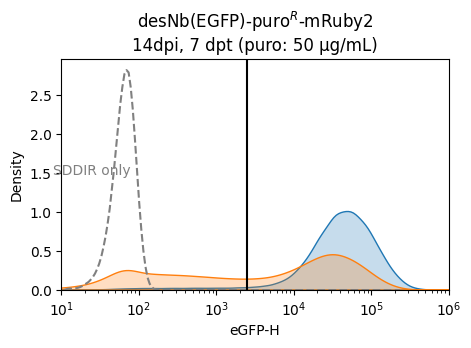

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Threshold for Hb9::GFP
eGFP_H_thresh = 2.5*10**3

# Plot eGFP-H
x = 'eGFP-H'

sns.kdeplot(data=df.loc[(df['retro-puro'] == 'des-Nb') & (df['puro_conc'] == 50)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=True)

sns.kdeplot(data=df.loc[(df['retro-puro'] == 'des-Nb') & (df['puro_conc'] == 0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=True)


# Plot 0 ug/mL ctrl
sns.kdeplot(data=df.loc[(df['retro-puro'] == 'SDDIR-only')],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate('SDDIR only', (0.08, 0.5), color='grey', xycoords='axes fraction', ha='center')


# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title('desNb(EGFP)-puro$^{R}$-mRuby2\n14dpi, 7 dpt (puro: 50 µg/mL)')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)


Creating summary dataframes

In [8]:
# Categorize iMNs based on eGFP_thresh
df['eGFP_cat'] = np.where(df['eGFP-H'] > eGFP_H_thresh, 'iMN', 'fib')

# Get total counts and percent of GFP-H+
group = ['retro-puro', 'puro_conc', 'biorep', 'scale']
count_df_reps = df.groupby([*group, 'well', 'eGFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')

# Get iMN yield per condition
data_iMN_count_reps = count_df_reps.reset_index(name='count')
data_total_count_reps = df.groupby([*group, 'well']).size().reset_index(name = 'total_count')

# Extract just the iMNs
data_iMN_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'iMN')]
data_iMN_count_reps = data_iMN_count_reps.loc[(data_iMN_count_reps['eGFP_cat'] == 'iMN')]

# Collapse to bio reps
# data_iMN_percent = data_iMN_percent_reps.groupby([*group]).mean().reset_index()
# data_iMN_count = data_iMN_count_reps.groupby([*group]).mean().reset_index()
data_iMN_percent = (
    data_iMN_percent_reps
    .groupby(group)
    .mean(numeric_only=True)
    .reset_index()
)

data_iMN_count = (
    data_iMN_count_reps
    .groupby(group)
    .mean(numeric_only=True)
    .reset_index()
)

data_total_count = (
    data_total_count_reps
    .groupby(group)
    .mean(numeric_only=True)
    .reset_index()
)

#calculating fold change relative to wtNb at 50 ug/mL puro
baseline = (
    data_iMN_percent
    .loc[
        (data_iMN_percent['retro-puro'] == 'WT-Nb') &
        (data_iMN_percent['puro_conc'] == 50)
    ]
    .groupby('scale')['percent']
    .mean()
)

data_iMN_percent['baseline'] = data_iMN_percent['scale'].map(baseline)

data_iMN_percent['fold_change'] = (
    data_iMN_percent['percent'] /
    data_iMN_percent['baseline']
)

data_purity_fc = (
    data_iMN_percent
    .groupby(group, as_index=False)['fold_change']
    .mean()
)

Analyzing 96-well scale

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_102196\3393991167.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


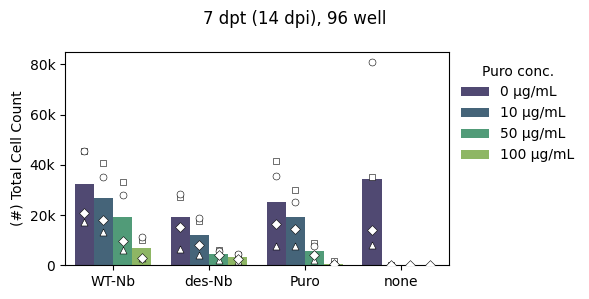

In [9]:
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
# General plotting params
x = 'retro-puro'
y = 'total_count'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50, 100]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

markers={1: 's', 2: 'o', 3: '^', 4:'D'}
outline_colors = {1: 'black', 2: 'black', 3: 'black', 4:'black'}

# Plot
sns.barplot(
    ax=ax, data=data_total_count[data_total_count['scale'] == '96-well'],
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=data_total_count[(data_total_count['biorep'] == rep) & (data_total_count['scale'] == '96-well')],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor=outline_colors[rep], linewidth=0.4,legend = False

    )

# sns.stripplot(
#     ax=ax, data=data_iMN_count_reps,
#     x=x, y=y,
#     order=order, hue=hue,
#     dodge=True, marker='o',
#     palette={puro:'white' for puro in hue_order}, size=5,
#     edgecolor='black', linewidth=0.4,legend = False)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('(#) Total Cell Count')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '50': '50 µg/mL',  '100': '100 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)




# Format
plt.suptitle('7 dpt (14 dpi), 96 well')
fig.tight_layout()  # Helps improve white spacing


Figure XX X 96 well total iMN yield

des-Nb_0 vs. des-Nb_50: ns
0.5×
Puro_0 vs. Puro_50: ns
0.4×
WT-Nb_0 vs. WT-Nb_50: ns
0.7×
WT-Nb_50 vs. des-Nb_50: ns
0.5×


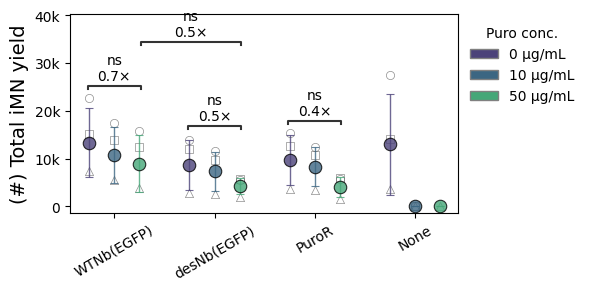

In [24]:
# General plotting params
x = 'retro-puro'
y = 'count'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]

# Plot iMN count of all cells

subset = data_iMN_count[
    (data_iMN_count['scale'] == '96-well') &
    (data_iMN_count['puro_conc'] != 100)
]

bio_means = (
    subset
    .groupby(['retro-puro', 'puro_conc', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['retro-puro', 'puro_conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data['retro-puro'] == cond) &
                (rep_data['puro_conc'] == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=0.45,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary['retro-puro'] == cond) &
            (summary['puro_conc'] == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=9,
            color=colors[puro],
            alpha=0.8,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

#Formatting

ax.yaxis.set_label_text('(#) Total iMN yield', fontsize=14)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_xticks(group_centers)

label_map = {
    'WT-Nb': 'WTNb(EGFP)',
    'des-Nb': 'desNb(EGFP)',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)



# Statistical tests

pairs = [
         (('WT-Nb', 0), ('WT-Nb', 50)),
         (('des-Nb', 0), ('des-Nb', 50)),
         (('Puro', 0), ('Puro', 50)),
         (('WT-Nb', 50), ('des-Nb', 50))
        

         ]

annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    fc = vals2.mean() / vals1.mean()

    annotations.append(f"{stars}\n{fc:.1f}×")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


fig.tight_layout()

plottitle = 'Figure_XX_iMN_6_count.svg'
plt.savefig(figpath + plottitle, bbox_inches='tight')

Figure XX X 96 well iMN purity

des-Nb_0 vs. des-Nb_50: ****
2.1×
Puro_0 vs. Puro_50: ***
1.8×
WT-Nb_0 vs. WT-Nb_50: ns
1.2×
WT-Nb_50 vs. des-Nb_50: ***
1.9×


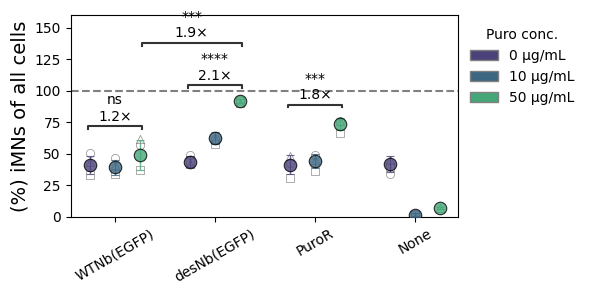

In [22]:
# General plotting params
x = 'retro-puro'
y = 'percent'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]

# Plot iMN percent of all cells

subset = data_iMN_percent[
    (data_iMN_percent['scale'] == '96-well') &
    (data_iMN_percent['puro_conc'] != 100)
]

bio_means = (
    subset
    .groupby(['retro-puro', 'puro_conc', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['retro-puro', 'puro_conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data['retro-puro'] == cond) &
                (rep_data['puro_conc'] == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=0.45,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary['retro-puro'] == cond) &
            (summary['puro_conc'] == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=9,
            color=colors[puro],
            alpha=0.8,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

#Formatting

ax.yaxis.set_label_text('(%) iMNs of all cells', fontsize=14)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,110)

ax.set_xticks(group_centers)

label_map = {
    'WT-Nb': 'WTNb(EGFP)',
    'des-Nb': 'desNb(EGFP)',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)


ax.axhline(
    100,
    color='grey',
    linestyle='--'
)


# Statistical tests

pairs = [
         (('WT-Nb', 0), ('WT-Nb', 50)),
         (('des-Nb', 0), ('des-Nb', 50)),
         (('Puro', 0), ('Puro', 50)),
         (('WT-Nb', 50), ('des-Nb', 50))
        

         ]

annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    fc = vals2.mean() / vals1.mean()

    annotations.append(f"{stars}\n{fc:.1f}×")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


fig.tight_layout()

plottitle = 'Figure_XX_iMN_6_purity.svg'
plt.savefig(figpath + plottitle, bbox_inches='tight')

Figure XX X purity fold change w.r.t. WT-Nb at 50 ug/mL

des-Nb_0 vs. des-Nb_50: ****
2.1×
Puro_0 vs. Puro_50: ***
1.8×
WT-Nb_0 vs. WT-Nb_50: ns
1.2×
WT-Nb_50 vs. des-Nb_50: ***
1.9×


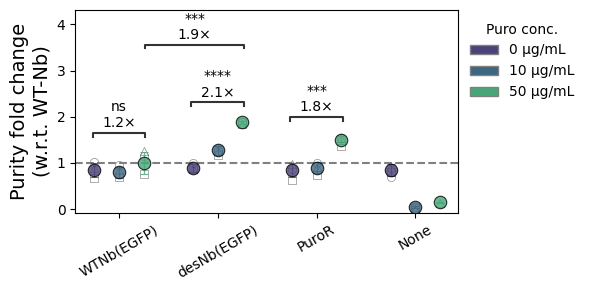

In [21]:
# General plotting params
x = 'retro-puro'
y = 'fold_change'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]

# Plot iMN count of all cells

subset = data_purity_fc[
    (data_purity_fc['scale'] == '96-well') &
    (data_purity_fc['puro_conc'] != 100)
]

bio_means = (
    subset
    .groupby(['retro-puro', 'puro_conc', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['retro-puro', 'puro_conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data['retro-puro'] == cond) &
                (rep_data['puro_conc'] == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=0.45,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary['retro-puro'] == cond) &
            (summary['puro_conc'] == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=9,
            color=colors[puro],
            alpha=0.8,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

#Formatting

ax.yaxis.set_label_text('Purity fold change\n(w.r.t. WT-Nb)', fontsize=14)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.axhline(1, 0, 1, color='grey', linestyle='--')
ax.set_yticks([0, 1, 2, 3, 4])

ax.set_xticks(group_centers)

label_map = {
    'WT-Nb': 'WTNb(EGFP)',
    'des-Nb': 'desNb(EGFP)',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)



# Statistical tests

pairs = [
         (('WT-Nb', 0), ('WT-Nb', 50)),
         (('des-Nb', 0), ('des-Nb', 50)),
         (('Puro', 0), ('Puro', 50)),
         (('WT-Nb', 50), ('des-Nb', 50))
        

         ]

annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    fc = vals2.mean() / vals1.mean()

    annotations.append(f"{stars}\n{fc:.1f}×")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


fig.tight_layout()

plottitle = 'Figure_XX_iMN_96_purity_fc.svg'
plt.savefig(figpath + plottitle, bbox_inches='tight')

Analyzing 6 well

Figure XX X 6 well iMN yield

des-Nb_0 vs. des-Nb_50: **
0.5×
Puro_0 vs. Puro_50: **
0.2×
WT-Nb_0 vs. WT-Nb_50: ns
0.8×
WT-Nb_50 vs. des-Nb_50: ns
0.5×


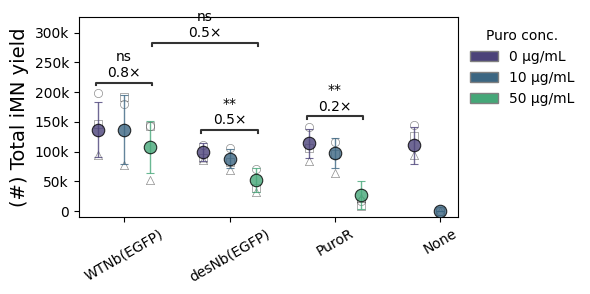

In [25]:
# General plotting params
x = 'retro-puro'
y = 'count'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]

# Plot iMN count of all cells

subset = data_iMN_count[
    (data_iMN_count['scale'] == '6-well') &
    (data_iMN_count['puro_conc'] != 100)
]

bio_means = (
    subset
    .groupby(['retro-puro', 'puro_conc', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['retro-puro', 'puro_conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data['retro-puro'] == cond) &
                (rep_data['puro_conc'] == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=0.45,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary['retro-puro'] == cond) &
            (summary['puro_conc'] == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=9,
            color=colors[puro],
            alpha=0.8,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

#Formatting

ax.yaxis.set_label_text('(#) Total iMN yield', fontsize=14)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)


ax.set_xticks(group_centers)

label_map = {
    'WT-Nb': 'WTNb(EGFP)',
    'des-Nb': 'desNb(EGFP)',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)


# Statistical tests

pairs = [
         (('WT-Nb', 0), ('WT-Nb', 50)),
         (('des-Nb', 0), ('des-Nb', 50)),
         (('Puro', 0), ('Puro', 50)),
         (('WT-Nb', 50), ('des-Nb', 50))
        

         ]

annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    fc = vals2.mean() / vals1.mean()

    annotations.append(f"{stars}\n{fc:.1f}×")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


fig.tight_layout()

plottitle = 'Figure_XX_iMN_6_count.svg'
plt.savefig(figpath + plottitle, bbox_inches='tight')

Fig XX X 6 well iMN purity

des-Nb_0 vs. des-Nb_50: ****
1.7×
Puro_0 vs. Puro_50: **
1.3×
WT-Nb_0 vs. WT-Nb_50: ***
1.3×
WT-Nb_50 vs. des-Nb_50: **
1.1×


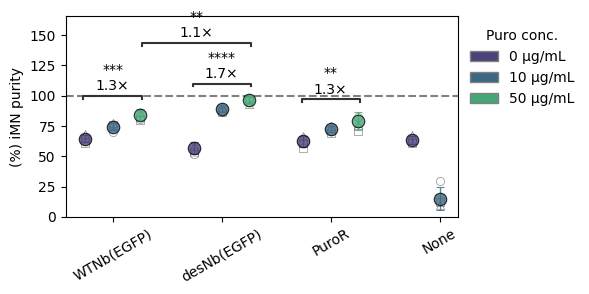

In [ ]:
# General plotting params
x = 'retro-puro'
y = 'percent'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]

# Plot iMN percent of all cells

subset = data_iMN_percent[
    (data_iMN_percent['scale'] == '6-well') &
    (data_iMN_percent['puro_conc'] != 100)
]

bio_means = (
    subset
    .groupby(['retro-puro', 'puro_conc', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['retro-puro', 'puro_conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data['retro-puro'] == cond) &
                (rep_data['puro_conc'] == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=0.45,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary['retro-puro'] == cond) &
            (summary['puro_conc'] == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=9,
            color=colors[puro],
            alpha=0.8,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

#Formatting

ax.yaxis.set_label_text('(%) iMNs of all cells', fontsize=14)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,110)

ax.set_xticks(group_centers)

label_map = {
    'WT-Nb': 'WTNb(EGFP)',
    'des-Nb': 'desNb(EGFP)',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)


ax.axhline(
    100,
    color='grey',
    linestyle='--'
)


# Statistical tests

pairs = [
         (('WT-Nb', 0), ('WT-Nb', 50)),
         (('des-Nb', 0), ('des-Nb', 50)),
         (('Puro', 0), ('Puro', 50)),
         (('WT-Nb', 50), ('des-Nb', 50))
        

         ]

annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    fc = vals2.mean() / vals1.mean()

    annotations.append(f"{stars}\n{fc:.1f}×")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


fig.tight_layout()

plottitle = 'Figure_XX_iMN_6_purity.svg'
plt.savefig(figpath + plottitle, bbox_inches='tight')

Figure XX NBW FACS/DASIT Comparisons

In [27]:
# Base dir for data files
path = rd.datadir /'data'/'attune'/ 'nat_attune' / 'desNb-circuits' / "2025.11.26_DASIT-iMN-purify_1-3"

# Data path
cache_path_7dpi = rd.rootdir/'output'/'Figure_5'/'data.gzip'

if cache_path_7dpi.exists():
    df_7dpi = pd.read_parquet(cache_path_7dpi)

else: 
    
    files = Path(path / 'export_singlets_7dpi').glob('*.csv')
    df_list = list()

    for i, file in enumerate(files):

        print(file.name)

        match = re.search('export_(?P<cond>.+)_Singlets.csv', file.name)

        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')

        # Load as df and note header is on 0th row
        df = pd.read_csv(file, header=0)

        # Update columns in df with metadata from file name
        if cond == 'Ctrl-neg':
            rep = 0
        elif cond[:3] == 'rep':
            rep = int(cond[3])
            cond = 'main'
            
        df['dpi'] = 7
        df['cond'] = cond
        df['rep'] = rep

        df_list.append(df)

    # Convert list of dfs into single df
    df_7dpi = pd.concat(df_list, ignore_index=True)

    # Shorten df
    channel_list = ['eGFP-H', 'dpi', 'cond', 'rep']
    df_7dpi = df_7dpi.loc[:, channel_list]

    # Save shortened df
    df_7dpi.to_parquet(rd.outfile(cache_path_7dpi))

export_Ctrl-neg_Singlets.csv
export_rep1_Singlets.csv
export_rep2_Singlets.csv
export_rep3_Singlets.csv


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [28]:
df_counts_7dpi = pd.read_excel(open(path/'2025.11.26_counts.xlsx', 'rb'), sheet_name='7 dpi summary') 

# Add in how many HG cells per 6well there is using hemocytometer data
for index, row in df_counts_7dpi.iterrows():

    df_counts_7dpi.loc[index, 'percent Hb9::EGFP+'] = row['Hb9::EGFP+ [frac]']*100
    df_counts_7dpi.loc[index, 'Cells per 6well'] = row['Cells per 6well [mil]']*1e6
    df_counts_7dpi.loc[index, 'HG cells per 6well [mil]'] = row['Cells per 6well [mil]']*row['Hb9::EGFP+ [frac]']

df_counts_7dpi

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

# Threshold for Hb9::GFP
# eGFP_H_thresh = 5e3
eGFP_H_thresh = 2e3
hue = 'rep'
palette = 'tab10'

# Plot eGFP-H
x = 'eGFP-H'
sns.kdeplot(data=df_7dpi.loc[(df_7dpi['cond'] != 'Ctrl-neg') & (df_7dpi[x]>0)], # (df_7dpi['rep'] == 1) & 
        ax=ax, x=x, hue=hue,
        common_norm=False, log_scale=(True, False), palette=palette,
        fill=True)


# Plot ctrl-neg
sns.kdeplot(data=df_7dpi.loc[(df_7dpi['cond'] == 'Ctrl-neg') & (df_7dpi[x]>0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate('Ctrl-neg', (0.32, 0.5), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'7 dpi | preReseed')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'dist-eGFP_7dpi.svg', bbox_inches='tight')